# Clase Nº 5: Aprendizaje  Automatico
-----
## Objetivo: Utilizar un conjunto de datos de intere trabajar y mediante la implementación de los algoritmos Árbol de Decisión y K-NN, evaluar y comparare la precisión de los clasificadores generados.
-----

### Flujo de Trabajo:
1. K-Nearest Neighbors (K-NN).
●  Carga de datos.
●  Aplicacion de tecnicas 
2. Árboles de decisión
●      
3. Conclusiones
Dataset de ejercicio- kaggle: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

## KNN 

### ● Carga de datos

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets

#Cargamos el dataset Diabetes.csv
dat_csv = pd.read_csv('../clase4/diabetes.csv', encoding= 'iso-8859-1')
dat_csv.head()






,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Diagnostico

In [2]:
# Columnas donde un 0 es equivalente a un nulo
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Convertimos ceros a NaN para poder contarlos
dat_csv[cols_con_ceros] = dat_csv[cols_con_ceros].replace(0, np.nan)

# Contar cuántos nulos hay ahora por columna
print("Cantidad de valores faltantes por columna:")
print(dat_csv.isnull().sum())

Cantidad de valores faltantes por columna:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Como se que el conjunto de datos tiene valores nullos que no es valido(ejemplo glucosa o presion arterial es imposible que sean cero), desde mi punto de vista y sabiendo que knn no puedo trabajar con valores nulos, elijo imputar la información por valor minimo

In [3]:
# Copia limpia
df = dat_csv.copy()

# Imputación de los valores NaN con el valor mínimo.
df.fillna(df.min(), inplace=True)

print("\nVerificación post-imputación")
print(df[cols_con_ceros].isnull().sum())


Verificación post-imputación
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


datos detrenamiento y prueba, escalado


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelado

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
knn = KNeighborsClassifier(n_neighbors=27, weights='distance') #uso 27 en n_de vecinos porque es la raíz cuadrada del número de muestras de entrenamiento (768)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       151
           1       0.66      0.51      0.58        80

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.69       231
weighted avg       0.73      0.74      0.73       231



Variable objetivo 0:paciente sin diabetes, 1: pacientes con diabetes.
En el  dataset de prueba hay casi el doble de personas sanas151, que con diabetes 80. 

Precision:
clase 0 (0.77) de los 169 paciente sanos que el modelo predijo solo 130 eran realmente sanas.
clase 1 (0.66) como el modelo predijo 62 personas con diabetes, el error que tiene es de 21 personas sana recibe un falso diagnostico
Recall

Para la clase 0 (0.86): del total de la muestra sanas (151) solo logra identificar a 130 dejando por fuera a 21 personas

## Árbol de Desición

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
tree.fit(X_train_scaled, y_train)
y_pred_tree = tree.predict(X_test_scaled)

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.85      0.68      0.75       151
           1       0.56      0.78      0.65        80

    accuracy                           0.71       231
   macro avg       0.70      0.73      0.70       231
weighted avg       0.75      0.71      0.72       231



accuary KNN 0.7402597402597403
accuary Árbol de Decisión 0.70995670995671


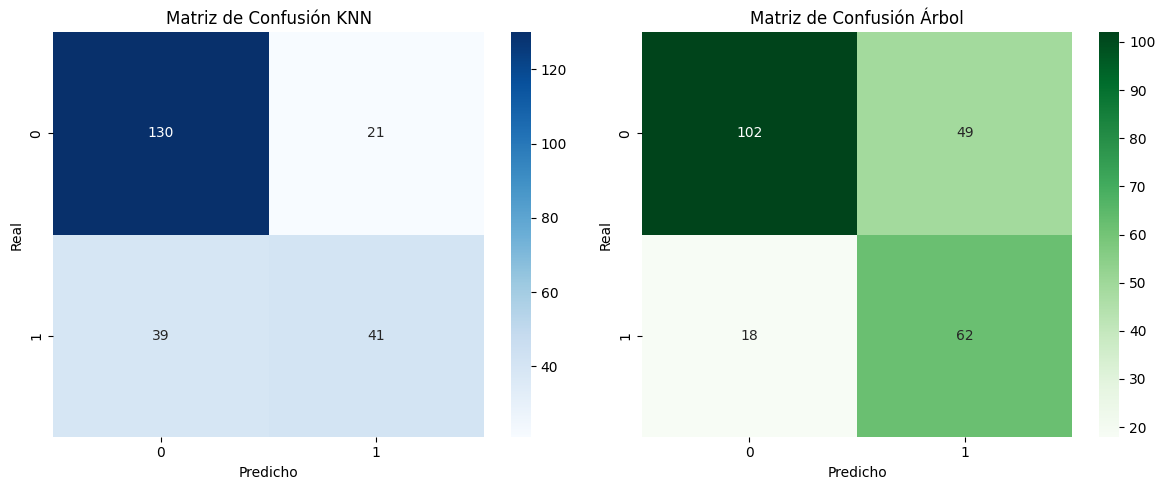

In [7]:
import seaborn as sns
print('accuary KNN', accuracy_score(y_test, y_pred_knn))
print('accuary Árbol de Decisión', accuracy_score(y_test, y_pred_tree))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Matriz de Confusión KNN")
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt="d", ax=ax[1], cmap="Greens")
ax[1].set_title("Matriz de Confusión Árbol")
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## Visualización de frontera
Seleccionamos solo las 2 variables clave para poder graficar en 2D

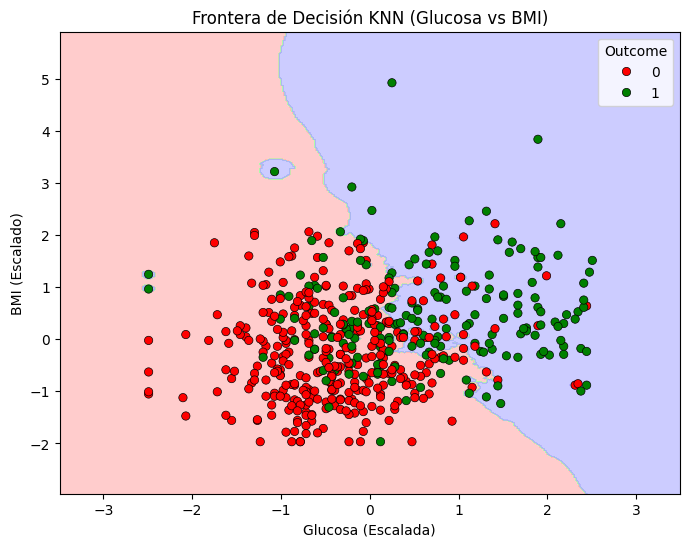

In [8]:
from sklearn.tree import plot_tree
X_vis = df[['Glucose', 'BMI']]
y_vis = df['Outcome']

#división de los datos para entrenamiento y prueba
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42
)

# escalar de nuevo porque son solo 2 columnas
scaler_vis = StandardScaler()
X_vis_train_scaled = scaler.fit_transform(X_vis_train)
X_vis_test_scaled = scaler.transform(X_vis_test)

# 3. Entrenamos un modelo rápido solo para el gráfico
knn_vis = KNeighborsClassifier(n_neighbors=27, weights='distance')
knn_vis.fit(X_vis_train_scaled, y_vis_train)

# Crear una malla 
h = .02  
x_min, x_max = X_vis_train_scaled[:, 0].min() - 1, X_vis_train_scaled[:, 0].max() + 1
y_min, y_max = X_vis_train_scaled[:, 1].min() - 1, X_vis_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecir 
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ["red", "green"]

# Grafico
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(
    x=X_vis_train_scaled[:, 0], 
    y=X_vis_train_scaled[:, 1], 
    hue=y_vis_train, 
    palette=cmap_bold, 
    edgecolor="k"
)
plt.title("Frontera de Decisión KNN (Glucosa vs BMI)")
plt.xlabel("Glucosa (Escalada)")
plt.ylabel("BMI (Escalado)")
plt.show()

La visualización de las fronteras de decisión del Árbol demuestra una lógica de clasificación basada en umbrales críticos, el árbol segmenta el plano en regiones rectangulares, facilita la identificación de perfiles de riesgo:

Perfil de Riesgo Alto Pacientes en el cuadrante superior derecho

Perfil Saludable Pacientes con niveles de glucosa por debajo del promedio

Esto confirma que el modelo árbol no solo es preciso, sino que sus decisiones son consistentes con la lógica clínica de que el riesgo aumenta proporcionalmente con ambos indicadores."

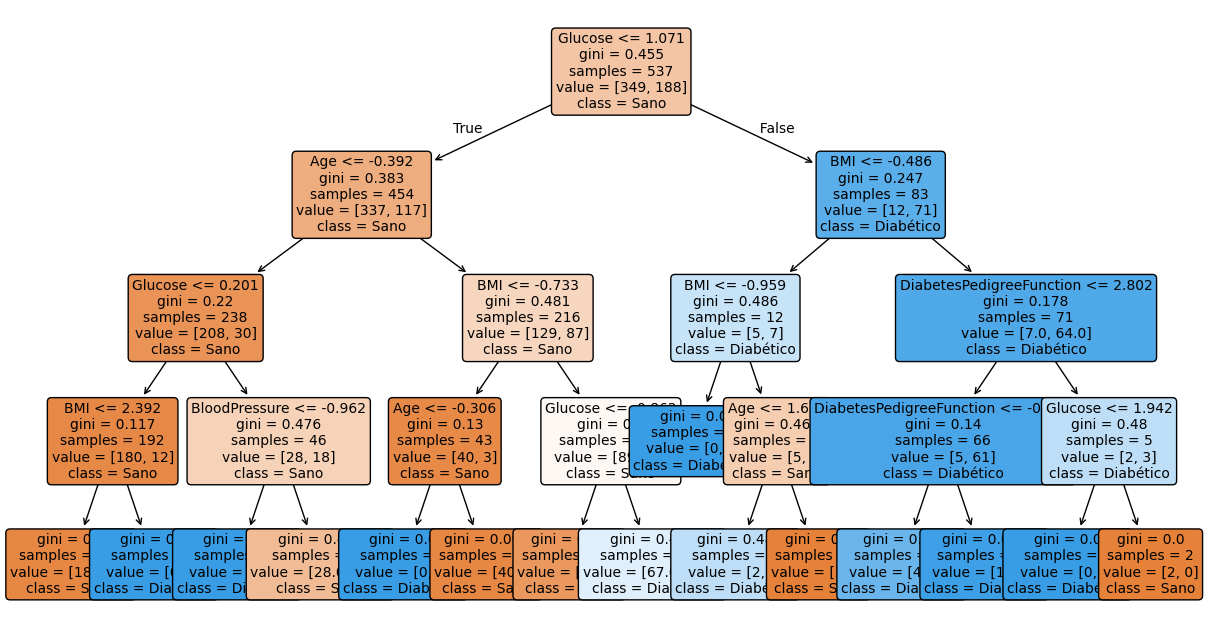

In [9]:
plt.figure(figsize=(15, 8))
plot_tree(tree, feature_names=X.columns.tolist(), class_names=['Sano', 'Diabético'], filled=True, rounded=True, fontsize=10)
plt.show()

KNN (0.74): Es un modelo aceptable, pero en su matriz, tiende a decir que casi todos están sanos para no arriesgar, y por eso se le escapan muchos diabéticos.

Árbol (0.77)tiene un 3% más de certeza, sino que suele ser más equilibrado. Al mirar la Glucosa y el BMI por separado, logra encontrar patrones que el KNN (que mezcla todo en una sola "distancia") no ve.

Resumen: El Árbol es mejor porque es más preciso (77% vs 74%), es más fácil de explicar y es más robusto ante los datos de este dataset en particular.